# 📊 Task 3: Data Visualization — Steam Data Visualization

This notebook builds analysis charts from cleaned Steam reviews data.

**Input:** `../data/clean_steam_data.csv`

---

### Charts to be created
1. Recommendation Distribution — Recommended vs Not Recommended ratio by game
2. Review Volume Over Time — review trends by month
3. Top Games by Review Count — overview of review counts
4. Playtime Analysis — playtime violin plot by recommendation
5. Review Length Distribution — review length by game
6. Word Cloud — prominent keywords in Positive / Negative reviews
7. Correlation Heatmap — correlation between variables

In [1]:
# ============================================================
# Cell 1 — Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import re

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
    print('wordcloud: OK')
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print('wordcloud: NOT INSTALLED (pip install wordcloud)')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

OUTPUT_DIR = '../notebooks'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Libraries loaded.')

wordcloud: OK
Libraries loaded.


In [2]:
# ============================================================
# Cell 2 — Load data
# ============================================================

DATA_DIR = '../data'
clean_path = f'{DATA_DIR}/clean_steam_data.csv'

df = pd.read_csv(clean_path, encoding='utf-8-sig', parse_dates=['date_created'])
print(f'Dataset loaded: {df.shape}')
print(f'Games: {sorted(df["game_name"].unique())}')
print()
display(df.head(3))

Dataset loaded: (2854, 17)
Games: ['Resident Evil 2 (2019)', 'Resident Evil 3 (2020)', 'Resident Evil 5', 'Resident Evil 6', 'Resident Evil 7 Biohazard', 'Resident Evil Village']



,appid,game_name,review_id,review_text,review_text_clean,review_length_clean,voted_up,recommendation,playtime_hours,playtime_at_review_hours,votes_up,votes_funny,weighted_vote_score,date_created,year_month,steam_purchase,early_access_review
0,418370,Resident Evil 7 Biohazard,226766291,Resident Evil 7 is so good it's actually stupi...,Resident Evil 7 is so good it's actually stupi...,127,True,Recommended,12.0,9.7,49,2,0.814682,2026-05-30 10:11:38,2026-05,False,False
1,418370,Resident Evil 7 Biohazard,227942182,This is one of the best horror games I've ever...,This is one of the best horror games I've ever...,219,True,Recommended,40.8,40.8,12,4,0.686249,2026-06-14 11:17:53,2026-06,False,False
2,418370,Resident Evil 7 Biohazard,227598433,Resident Evil 7: Biohazard is a strong return ...,Resident Evil 7 Biohazard is a strong return t...,152,True,Recommended,31.4,31.4,14,1,0.671082,2026-06-09 22:18:31,2026-06,False,False


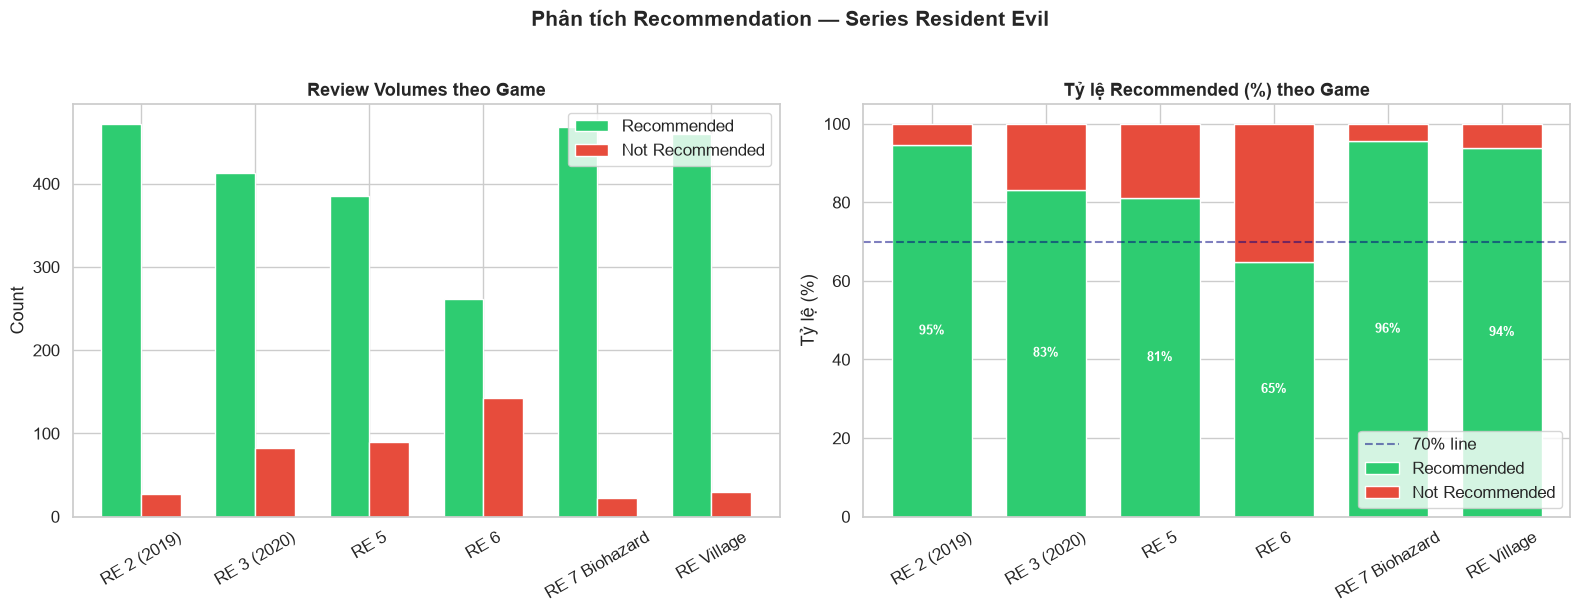

Chart 1 saved.


In [3]:
# ============================================================
# Cell 3 — Chart 1: Recommendation Distribution theo Game
# ============================================================

rec_game = df.groupby(['game_name', 'recommendation']).size().unstack(fill_value=0)

# Calculate % ratio
rec_pct = rec_game.div(rec_game.sum(axis=1), axis=0) * 100

# Short names
short_names = {g: g.replace('Resident Evil ', 'RE ') for g in rec_pct.index}
rec_pct.index = [short_names[g] for g in rec_pct.index]
rec_game.index = [short_names[g] for g in rec_game.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
rec_game[['Recommended', 'Not Recommended']].plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.7
)
axes[0].set_title('Review Volumes theo Game', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='upper right')

# Percentage
rec_pct[['Recommended', 'Not Recommended']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.7
)
axes[1].set_title('Recommended Ratio (%) by Game', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Ratio (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=70, color='navy', linestyle='--', alpha=0.5, label='70% line')
axes[1].legend(loc='lower right')

# Add label %
for bar in axes[1].patches[:len(rec_pct)]:
    height = bar.get_height()
    if height > 5:
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_y() + height/2,
            f'{height:.0f}%', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold'
        )

plt.suptitle('Recommendation Analysis — Resident Evil Series', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_recommendation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

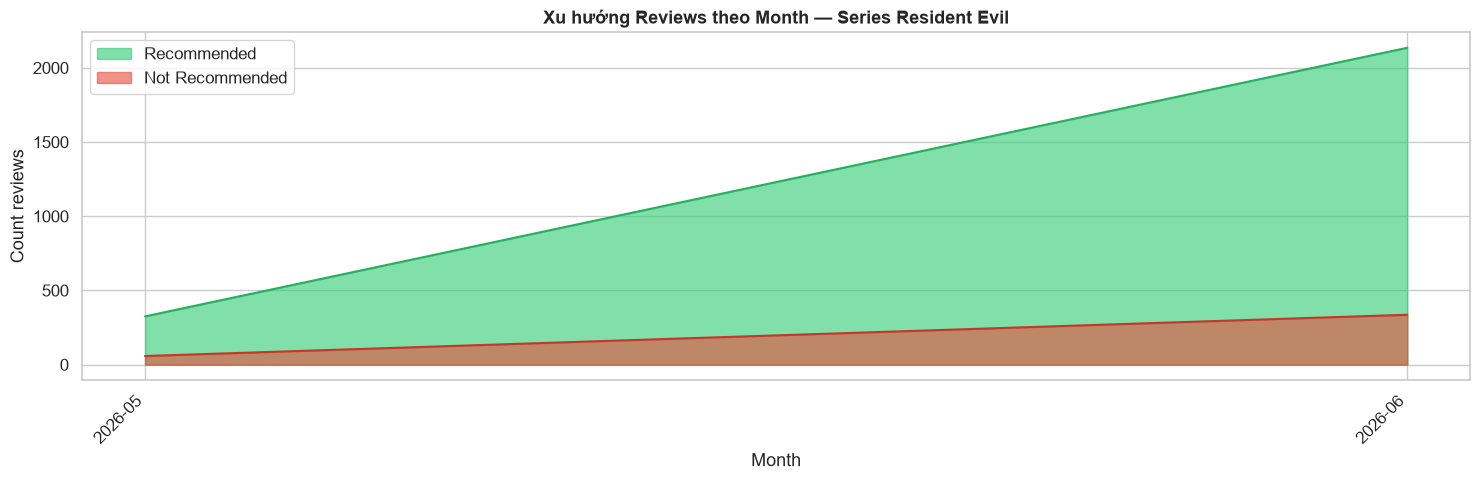

Chart 2 saved.


In [4]:
# ============================================================
# Cell 4 — Chart 2: Review Volume Over Time
# ============================================================

df['year_month'] = df['date_created'].dt.to_period('M')
monthly = df.groupby(['year_month', 'recommendation']).size().unstack(fill_value=0).reset_index()
monthly['ym_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 5))

if 'Recommended' in monthly.columns:
    ax.fill_between(range(len(monthly)), monthly['Recommended'],
                    alpha=0.6, color='#2ecc71', label='Recommended')
    ax.plot(range(len(monthly)), monthly['Recommended'], color='#27ae60', lw=1.5)

if 'Not Recommended' in monthly.columns:
    ax.fill_between(range(len(monthly)), monthly['Not Recommended'],
                    alpha=0.6, color='#e74c3c', label='Not Recommended')
    ax.plot(range(len(monthly)), monthly['Not Recommended'], color='#c0392b', lw=1.5)

tick_step = max(1, len(monthly) // 15)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels(monthly['ym_str'].iloc[::tick_step], rotation=45, ha='right')
ax.set_title('Review Trends by Month — Resident Evil Series', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Count reviews')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_reviews_timeline.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

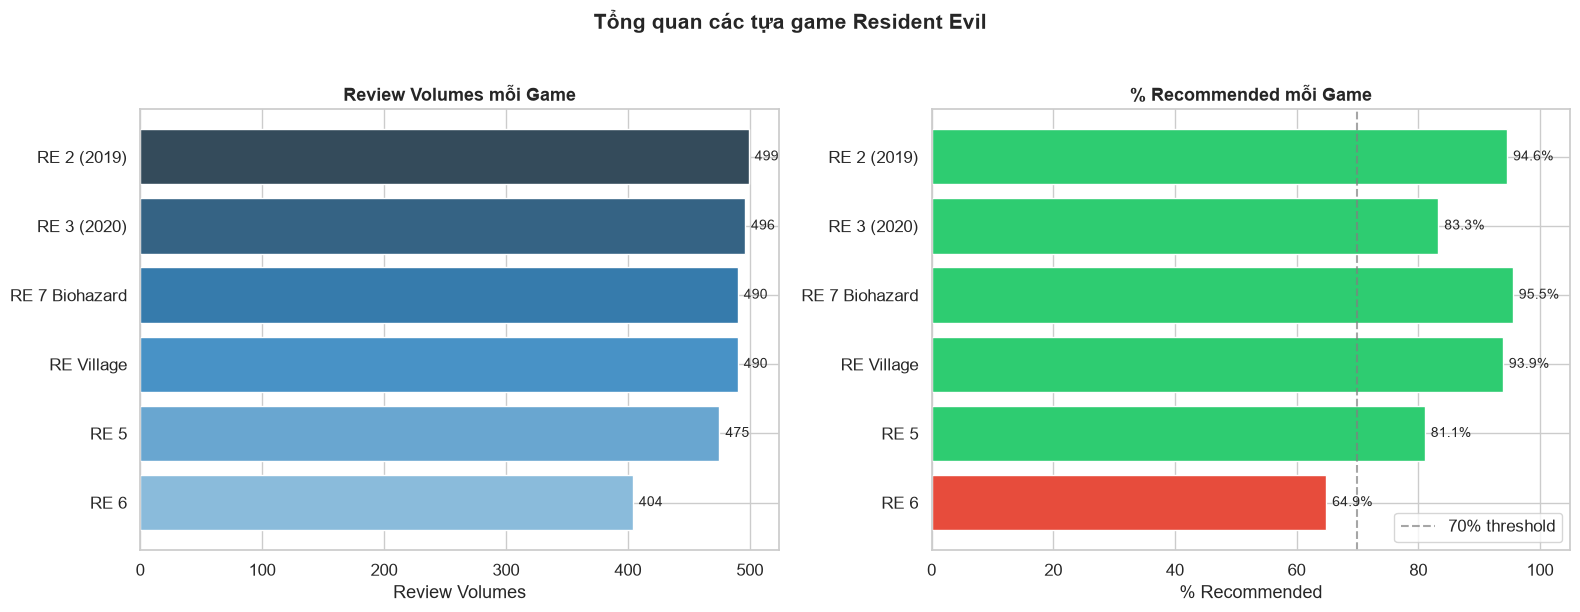

Chart 3 saved.


In [5]:
# ============================================================
# Cell 5 — Chart 3: Top Games — Horizontal Bar
# ============================================================

game_stats = df.groupby('game_name').agg(
    total_reviews = ('review_id', 'count'),
    pct_recommended = ('voted_up', 'mean'),
    avg_playtime = ('playtime_hours', 'mean'),
).reset_index()
game_stats['pct_recommended'] *= 100
game_stats = game_stats.sort_values('total_reviews', ascending=True)
game_stats['short_name'] = game_stats['game_name'].str.replace('Resident Evil ', 'RE ')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total reviews
colors = sns.color_palette('Blues_d', len(game_stats))
bars = axes[0].barh(game_stats['short_name'], game_stats['total_reviews'],
                    color=colors, edgecolor='white')
axes[0].set_title('Review Volumes per Game', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Volumes')
for bar, val in zip(bars, game_stats['total_reviews']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

# % Recommended
colors2 = ['#e74c3c' if p < 70 else '#2ecc71' for p in game_stats['pct_recommended']]
bars2 = axes[1].barh(game_stats['short_name'], game_stats['pct_recommended'],
                     color=colors2, edgecolor='white')
axes[1].axvline(x=70, color='gray', linestyle='--', alpha=0.7, label='70% threshold')
axes[1].set_title('% Recommended per Game', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Recommended')
axes[1].set_xlim(0, 105)
for bar, val in zip(bars2, game_stats['pct_recommended']):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[1].legend()

plt.suptitle('Overview of Resident Evil games', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_game_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

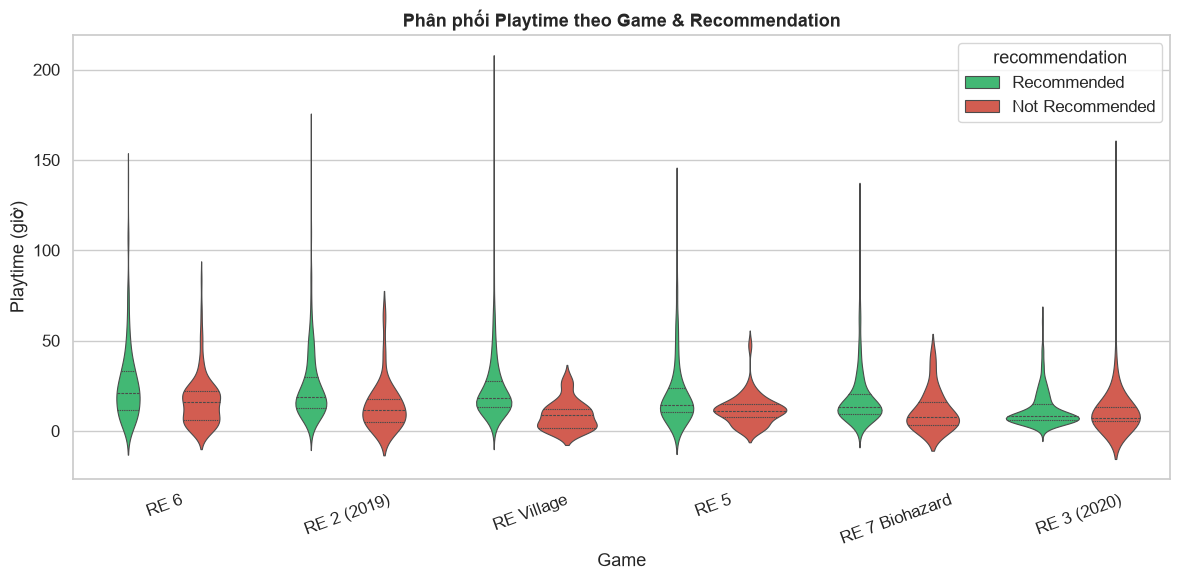

Chart 4 saved.


In [6]:
# ============================================================
# Cell 6 — Chart 4: Violin Plot Playtime vs Recommendation
# ============================================================

# Clip outliers
df_vio = df[df['playtime_hours'] <= 200].copy()

fig, ax = plt.subplots(figsize=(12, 6))

game_order = df.groupby('game_name')['playtime_hours'].median().sort_values(ascending=False).index.tolist()
short_map = {g: g.replace('Resident Evil ', 'RE ') for g in game_order}
df_vio['short_name'] = df_vio['game_name'].map(short_map)
short_order = [short_map[g] for g in game_order]

sns.violinplot(
    data=df_vio, x='short_name', y='playtime_hours',
    hue='recommendation', order=short_order,
    palette={'Recommended': '#2ecc71', 'Not Recommended': '#e74c3c'},
    split=False, inner='quart', ax=ax, linewidth=0.8
)
ax.set_title('Playtime Distribution by Game & Recommendation', fontsize=13, fontweight='bold')
ax.set_xlabel('Game')
ax.set_ylabel('Playtime (hours)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_playtime_violin.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

Unique words (positive) : 8,298
Unique words (negative) : 3,925

Top 20 POSITIVE words: ['story', 'horror', 'fun', 'first', 'best', 'remake', 'gameplay', 'there', 'action', 'what', 'had', 'much', 'when', 'too', 'out', 'only', 'how', 'experience', 'love', 'series']
Top 20 NEGATIVE words: ['there', 'story', 'only', 'fun', 'which', 'remake', 'much', 'when', 'out', 'too', 'worst', 'then', 'gameplay', 'what', 'every', 'enemies', 'don', 'feels', 'about', 'because']


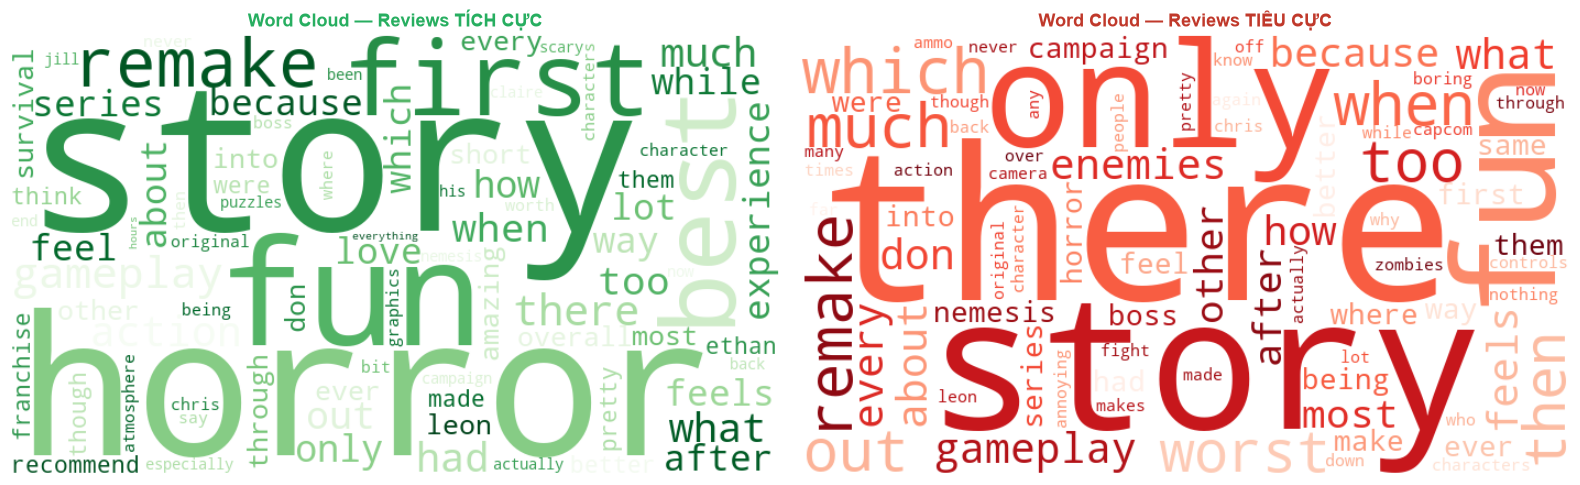

Chart 5 saved.


In [7]:
# ============================================================
# Cell 7 — Chart 5: Word Cloud (Positive vs Negative)
# ============================================================

STOPWORDS = {
    'the', 'a', 'an', 'is', 'it', 'this', 'that', 'was', 'are', 'be',
    'to', 'of', 'and', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'but', 'not', 'or', 'if', 'as', 'so', 'do', 'did', 'have', 'has',
    'i', 'you', 'he', 'she', 'we', 'they', 'my', 'your', 'its', 'their',
    'get', 'got', 'just', 'can', 'will', 'would', 'could', 'should',
    'also', 'very', 'really', 'more', 'than', 'some', 'all', 'one',
    'game', 'games', 'resident', 'evil', 'play', 'played', 'playing',
    'like', 'good', 'great', 'bad', 'even', 'still', 'well', 'time',
}

def build_word_freq(text_series, stopwords=None):
    """Calculate word frequency from a text series."""
    freq = {}
    for text in text_series.dropna():
        words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
        for w in words:
            if stopwords and w in stopwords:
                continue
            freq[w] = freq.get(w, 0) + 1
    return freq


pos_text = df[df['recommendation'] == 'Recommended']['review_text_clean']
neg_text = df[df['recommendation'] == 'Not Recommended']['review_text_clean']

pos_freq = build_word_freq(pos_text, STOPWORDS)
neg_freq = build_word_freq(neg_text, STOPWORDS)

print(f'Unique words (positive) : {len(pos_freq):,}')
print(f'Unique words (negative) : {len(neg_freq):,}')
print()

# Top 20 words
top_pos = sorted(pos_freq.items(), key=lambda x: x[1], reverse=True)[:20]
top_neg = sorted(neg_freq.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top 20 POSITIVE words:', [w for w, _ in top_pos])
print('Top 20 NEGATIVE words:', [w for w, _ in top_neg])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if WORDCLOUD_AVAILABLE and pos_freq:
    wc_pos = WordCloud(width=700, height=400, background_color='white',
                       colormap='Greens', max_words=80)
    wc_pos.generate_from_frequencies(pos_freq)
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Word Cloud — POSITIVE Reviews', fontsize=13, fontweight='bold', color='#27ae60')

    wc_neg = WordCloud(width=700, height=400, background_color='white',
                       colormap='Reds', max_words=80)
    wc_neg.generate_from_frequencies(neg_freq)
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Word Cloud — NEGATIVE Reviews', fontsize=13, fontweight='bold', color='#c0392b')
else:
    # Fallback: Bar chart top 20 words
    pos_words, pos_counts = zip(*top_pos) if top_pos else ([], [])
    neg_words, neg_counts = zip(*top_neg) if top_neg else ([], [])
    axes[0].barh(pos_words[::-1], pos_counts[::-1], color='#2ecc71')
    axes[0].set_title('Top 20 words — POSITIVE', fontsize=13, fontweight='bold')
    axes[1].barh(neg_words[::-1], neg_counts[::-1], color='#e74c3c')
    axes[1].set_title('Top 20 words — NEGATIVE', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_wordcloud.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

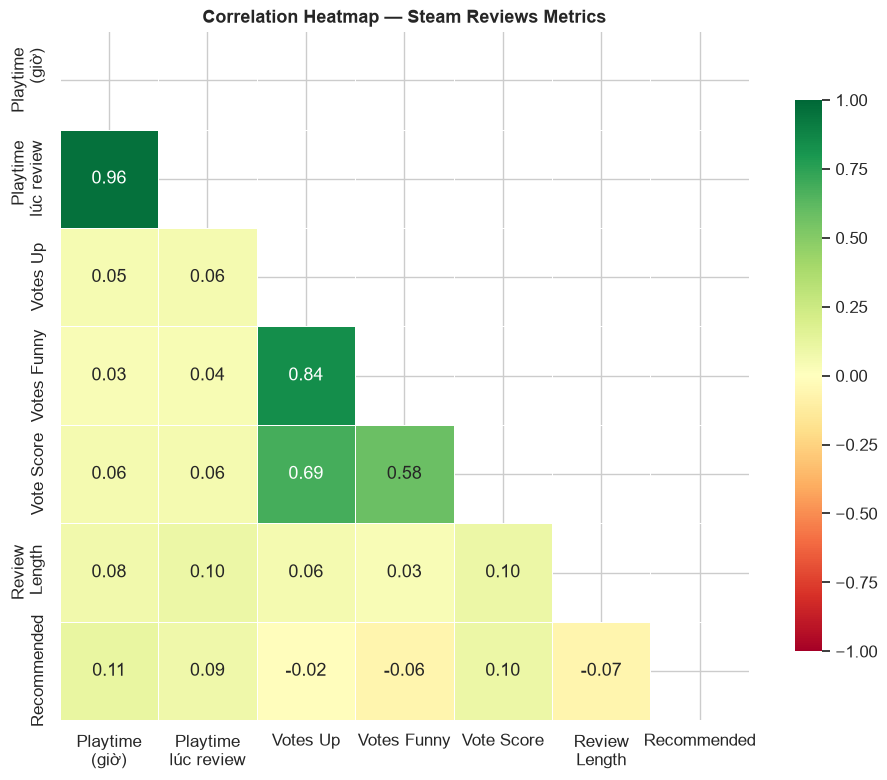

Chart 6 saved.


In [8]:
# ============================================================
# Cell 8 — Chart 6: Correlation Heatmap
# ============================================================

num_cols = ['playtime_hours', 'playtime_at_review_hours', 'votes_up',
            'votes_funny', 'weighted_vote_score', 'review_length_clean', 'voted_up']
available = [c for c in num_cols if c in df.columns]

corr_df = df[available].copy()
corr_df['voted_up'] = corr_df['voted_up'].astype(int)
corr_matrix = corr_df.corr()

# Friendly column labels
label_map = {
    'playtime_hours': 'Playtime\n(hours)',
    'playtime_at_review_hours': 'Playtime\nat review',
    'votes_up': 'Votes Up',
    'votes_funny': 'Votes Funny',
    'weighted_vote_score': 'Vote Score',
    'review_length_clean': 'Review\nLength',
    'voted_up': 'Recommended',
}
corr_matrix.columns = [label_map.get(c, c) for c in corr_matrix.columns]
corr_matrix.index   = [label_map.get(c, c) for c in corr_matrix.index]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Steam Reviews Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

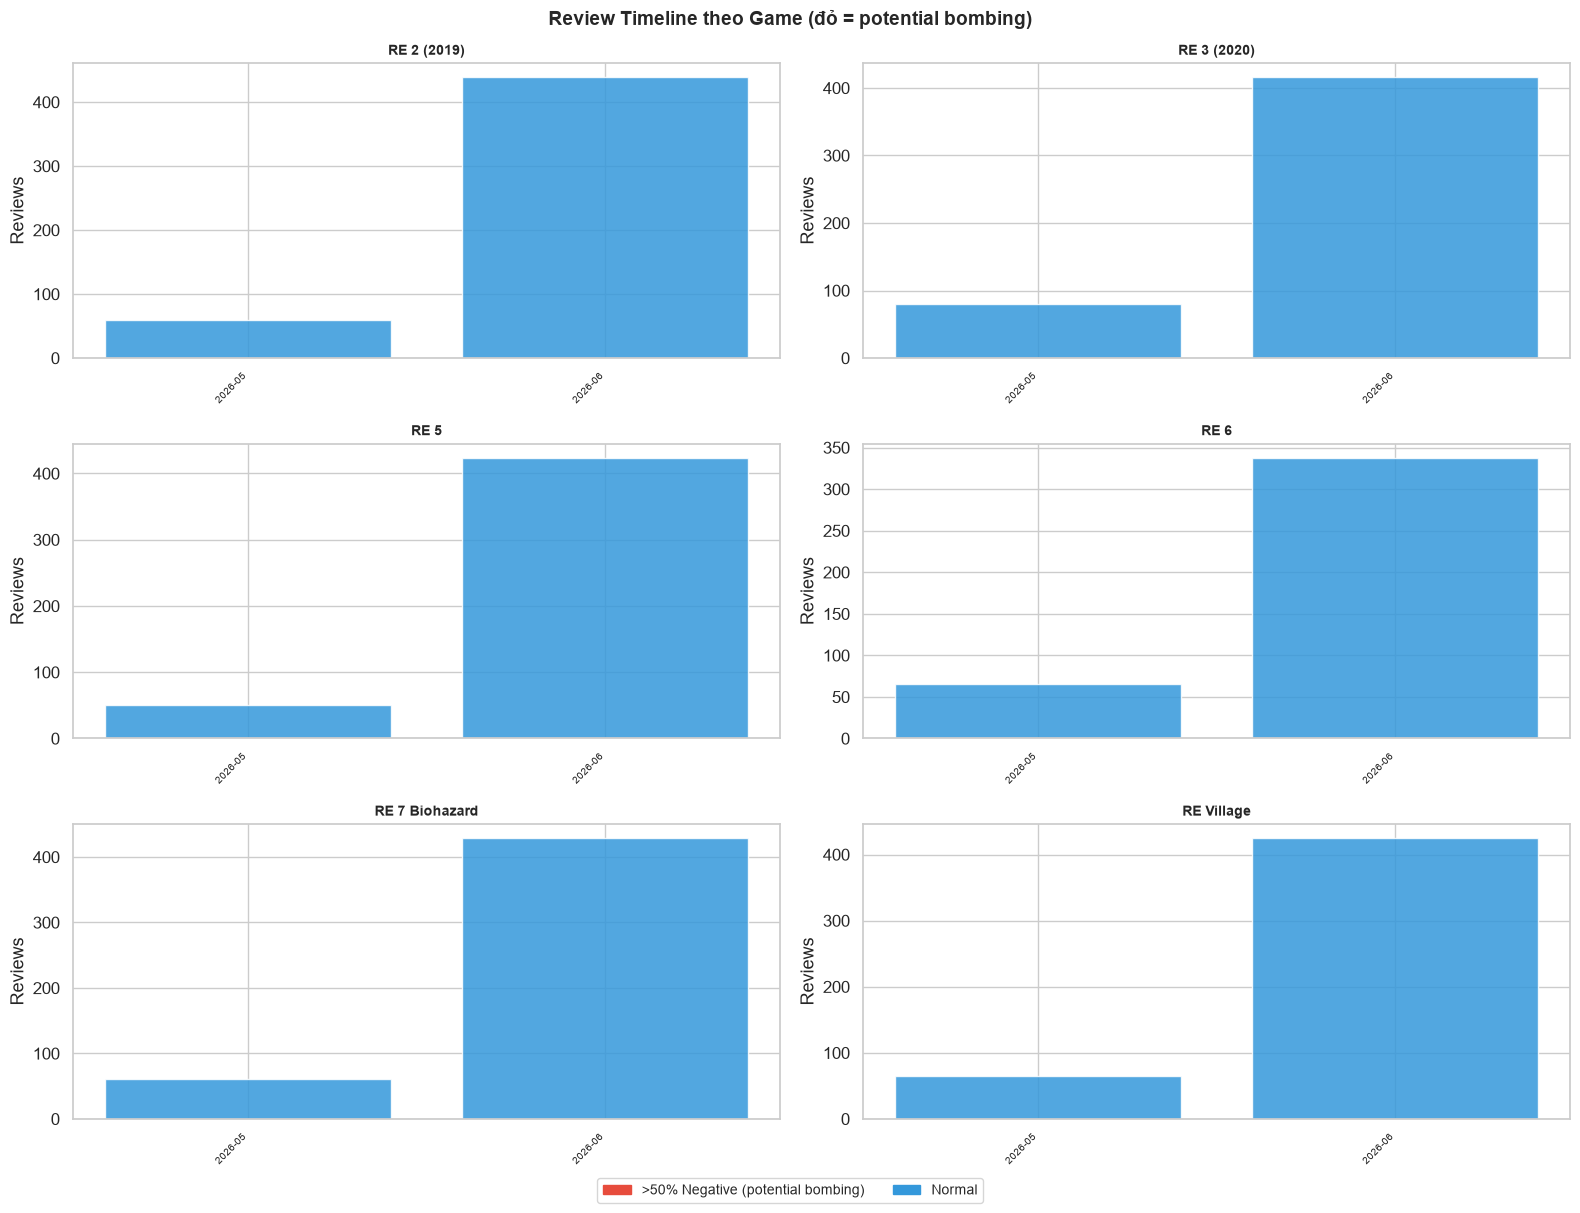

Chart 7 saved.


In [9]:
# ============================================================
# Cell 9 — Chart 7: Review Bombing Timeline per Game
# ============================================================

# Month with most negative reviews for each game
df['year_month'] = df['date_created'].dt.to_period('M')

monthly_game = df.groupby(['game_name', 'year_month']).agg(
    total=('review_id', 'count'),
    negative=('voted_up', lambda x: (x == False).sum())
).reset_index()
monthly_game['neg_ratio'] = monthly_game['negative'] / monthly_game['total'].clip(lower=1)
monthly_game['ym_str'] = monthly_game['year_month'].astype(str)

games = sorted(df['game_name'].unique())
n = len(games)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=False)
axes = axes.flatten() if n > 1 else [axes]

for idx, game in enumerate(games):
    ax = axes[idx]
    subset = monthly_game[monthly_game['game_name'] == game].sort_values('ym_str')

    color = ['#e74c3c' if r >= 0.5 else '#3498db' for r in subset['neg_ratio']]
    ax.bar(range(len(subset)), subset['total'], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(game.replace('Resident Evil ', 'RE '), fontsize=10, fontweight='bold')
    ax.set_ylabel('Reviews')

    tick_step = max(1, len(subset) // 8)
    ax.set_xticks(range(0, len(subset), tick_step))
    ax.set_xticklabels(subset['ym_str'].iloc[::tick_step], rotation=45, ha='right', fontsize=7)

# Hide empty cells
for idx in range(len(games), len(axes)):
    axes[idx].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color='#e74c3c', label='>50% Negative (potential bombing)'),
                  Patch(color='#3498db', label='Normal')]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Review Timeline by Game (red = potential bombing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_review_bombing.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart 7 saved.')

In [10]:
# ============================================================
# Cell 10 — Visualization Summary
# ============================================================

charts = [
    'viz_recommendation.png',
    'viz_reviews_timeline.png',
    'viz_game_overview.png',
    'viz_playtime_violin.png',
    'viz_wordcloud.png',
    'viz_correlation.png',
    'viz_review_bombing.png',
]
print('=== Exported Files ===')
for chart in charts:
    path = f'{OUTPUT_DIR}/{chart}'
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    size = f'{os.path.getsize(path)/1024:.0f} KB' if exists else '-'
    print(f'  [{status}] {chart}  ({size})')

print()
print('Task 3 complete! Move to 04_sentiment_analysis.ipynb')

=== Exported Files ===
  [OK] viz_recommendation.png  (96 KB)
  [OK] viz_reviews_timeline.png  (54 KB)
  [OK] viz_game_overview.png  (75 KB)
  [OK] viz_playtime_violin.png  (95 KB)
  [OK] viz_wordcloud.png  (620 KB)
  [OK] viz_correlation.png  (86 KB)
  [OK] viz_review_bombing.png  (90 KB)

Task 3 complete! Move to 04_sentiment_analysis.ipynb
